# Time Series Forecasting of Carbon Credit Prices (EUA) using SARIMAX and LSTM

# 1. Imports and Configuration

This section is dedicated to importing all necessary Python libraries and setting up the configuration parameters for reproducibility.

**Importing Libraries**: Various libraries like `pandas`, `numpy`, `matplotlib`, `sklearn`, and `torch` are imported for data manipulation, numerical operations, plotting, machine learning utilities, and deep learning framework, respectively. Importing these at the beginning ensures all required functionalities are available throughout the notebook.

**Setting Random Seeds**: For any work involving random processes (e.g., neural network initialization, data splitting, sampling), setting a `SEED` (or multiple seeds for different libraries like `torch`, `numpy`, `random`) is crucial. It ensures that every time the notebook is run, the same "random" sequence is generated. This is vital for:
*   **Reproducibility**: Allowing others (or yourself in the future) to replicate the exact results obtained.
*   **Debugging**: Making it easier to trace issues since the random components are fixed.
*   **Fair Comparison**: Ensuring that model comparisons are fair, as variations due to randomness are minimized.

In [1]:
# Imports & seeds

import math
import random
from pathlib import Path
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [2]:
# FILES = [
#     "/kaggle/input/dataset-carbon/Brent-Oil-Futures-Historical-Data.xlsx",
#     "/kaggle/input/dataset-carbon/CAC 40 Historical Data.xlsx",
#     "/kaggle/input/dataset-carbon/DAX Historical Data.xlsx",
#     "/kaggle/input/dataset-carbon/Euro Stoxx 50 Historical Data.xlsx",
#     "/kaggle/input/dataset-carbon/European Union Allowance (EUA) Yearly Futures Historical Data.xlsx",
#     "/kaggle/input/dataset-carbon/FTSE 100 Historical Data.xlsx",
#     "/kaggle/input/dataset-carbon/ICE Dutch TTF Natural Gas Futures Historical Data.xlsx",
#     "/kaggle/input/dataset-carbon/Rotterdam Coal Futures Historical Data.xlsx",
#     "/kaggle/input/dataset-carbon/UK NBP Natural Gas Yearly Futures Historical Data.xlsx",
#     "/kaggle/input/dataset-carbon/USD_EUR Historical Data.xlsx"
# ]
# SHORT = {
#     "Brent Oil Futures Historical Data": "BRENT",
#     "CAC 40 Historical Data": "CAC",
#     "DAX Historical Data": "DAX",
#     "Euro Stoxx 50 Historical Data": "EURO50",
#     "European Union Allowance (EUA) Yearly Futures Historical Data": "EUA",
#     "FTSE 100 Historical Data": "FTSE",
#     "ICE Dutch TTF Natural Gas Futures Historical Data": "TTF",
#     "Rotterdam Coal Futures Historical Data": "COAL",
#     "UK NBP Natural Gas Yearly Futures Historical Data": "NBP",
#     "USD_EUR Historical Data": "USD_EUR"
# }

In [3]:
# # OUTPUT
# OUT_MERGED_CSV = "merged_prices_raw.csv"
# OUT_MERGED_FILLED_CSV = "merged_prices_filled.csv"

# # -----------------------
# # Helpers: detect date & price columns robustly
# # -----------------------
# def clean_numeric(s):
#     return pd.to_numeric(s.astype(str).str.replace(r'[^\d\.\-]', '', regex=True), errors='coerce')

# def detect_date_col(df):
#     for c in df.columns:
#         if "date" in str(c).lower() or "time" in str(c).lower():
#             return c
#     # fallback: column yielding most non-null parseable datetimes
#     best, bestn = None, -1
#     for c in df.columns:
#         n = pd.to_datetime(df[c], errors='coerce', dayfirst=True).notna().sum()
#         if n > bestn:
#             best, bestn = c, n
#     return best if bestn > 0 else df.columns[0]

# def detect_price_col(df, date_col):
#     # choose first non-date numeric-like column (heuristic)
#     candidates = [c for c in df.columns if c != date_col]
#     # try keywords
#     kws = ("price","close","last","value","price","adj","mid")
#     for c in candidates:
#         if any(k in str(c).lower() for k in kws):
#             return c
#     # fallback: choose column with most parseable numerics
#     best = None; bestn = -1
#     for c in candidates:
#         n = clean_numeric(df[c]).notna().sum()
#         if n > bestn:
#             best, bestn = c, n
#     return best if best is not None else (candidates[0] if candidates else None)

# def read_price_file(path):
#     p = Path(path)
#     if not p.exists():
#         raise FileNotFoundError(f"File not found: {path}")
#     # try a few header offsets (some excel exports have header rows)
#     for header in range(0, 4):
#         try:
#             df = pd.read_excel(p, header=header)
#         except Exception:
#             continue
#         if df.shape[0] == 0:
#             continue
#         dcol = detect_date_col(df)
#         pcol = detect_price_col(df, dcol)
#         if dcol is None or pcol is None:
#             continue
#         dates = pd.to_datetime(df[dcol], errors='coerce', dayfirst=True)
#         prices = clean_numeric(df[pcol])
#         out = pd.DataFrame({"Date": dates.dt.normalize(), p.stem: prices})
#         out = out.dropna(subset=["Date"]).groupby("Date", as_index=False).mean()
#         return out
#     raise RuntimeError(f"Cannot parse {path}")



In [4]:
# # -----------------------
# # Load all files -> dict of dataframes
# # -----------------------
# dfs = {}
# for path in FILES:
#     try:
#         dfp = read_price_file(path)
#         # rename column to SHORT if mapping exists
#         stem = Path(path).stem
#         short = SHORT.get(stem, stem[:12].replace(" ", "_"))
#         # sometimes read_price_file returns column named by stem; rename:
#         col = [c for c in dfp.columns if c != "Date"][0]
#         dfp = dfp.rename(columns={col: short})
#         dfs[short] = dfp
#         print(f"Loaded {path} -> {len(dfp)} rows as '{short}'")
#     except Exception as e:
#         print(f"Skip {path}: {e}")

# if len(dfs) == 0:
#     raise SystemExit("No files loaded. Check FILES paths.")

# # -----------------------
# # Merge all on Date (outer join to keep full timeline)
# # -----------------------
# merged = None
# for k, d in dfs.items():
#     if merged is None:
#         merged = d.copy()
#     else:
#         merged = merged.merge(d, on="Date", how="outer")

# merged = merged.sort_values("Date").reset_index(drop=True)
# merged = merged.set_index("Date")

# # Save raw merged
# merged.to_csv(OUT_MERGED_CSV)
# print(f"\nSaved raw merged -> {OUT_MERGED_CSV}")



In [5]:
# # -----------------------
# # Missing value stats BEFORE
# # -----------------------
# print("\nMissing BEFORE (count per column):")
# print(merged.isna().sum().sort_values(ascending=False))

# # -----------------------
# # Interpolate by neighbor-mean (mean of n-1 and n+1) iteratively
# # -----------------------
# df = merged.copy()

# it = 0
# while True:
#     prev = df.shift(1)
#     nxt = df.shift(-1)
#     mask = df.isna() & prev.notna() & nxt.notna()
#     if not mask.any().any():
#         break
#     fill_vals = (prev + nxt) / 2.0
#     df = df.where(~mask, fill_vals)
#     it += 1
#     if it > 5000:
#         # safety break (shouldn't occur)
#         break

# print(f"\nNeighbor-mean interpolation iterations: {it}")

# # Fill remaining with forward/backward fill (edges or long gaps)
# df = df.ffill().bfill()

# # As final fallback, fill any remaining missing with column median (should be rare)
# remaining = df.isna().sum()
# if remaining.sum() > 0:
#     for c, cnt in remaining[remaining > 0].items():
#         med = merged[c].median()
#         df[c] = df[c].fillna(med if not np.isnan(med) else 0.0)

# # -----------------------
# # Missing value stats AFTER
# # -----------------------
# print("\nMissing AFTER (count per column):")
# print(df.isna().sum().sort_values(ascending=False))

# # Save filled
# df.reset_index().to_csv(OUT_MERGED_FILLED_CSV, index=False)
# print(f"\nSaved neighbor-filled merged -> {OUT_MERGED_FILLED_CSV}")



In [6]:
# LOAD DATASET

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from keras.models import Sequential
from keras.layers import Dense, LSTM
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import seaborn as sns


df = pd.read_excel('/kaggle/input/dataset-carbon/merged_prices_filled.xlsx')

df.head()

2026-01-01 04:05:46.595265: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767240346.985245      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767240347.082989      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767240348.171851      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767240348.171895      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767240348.171898      24 computation_placer.cc:177] computation placer alr

,Date,BRENT,CAC,DAX,EURO50,EUA,FTSE,TTF,COAL,NBP,USD_EUR
0,2012-01-02,112.13,3222.30,6075.52,2370.20,6.60,5699.91,21.60,109.35,62.90,0.7734
1,2012-01-03,112.13,3245.40,6166.57,2389.91,6.60,5699.91,21.60,109.35,62.90,0.7664
2,2012-01-04,113.70,3193.65,6111.55,2349.89,6.57,5668.45,21.87,109.55,63.49,0.7726
3,2012-01-05,112.74,3144.91,6095.99,2315.75,6.72,5624.26,21.79,110.10,63.54,0.7823
4,2012-01-06,113.06,3137.36,6057.92,2298.65,6.60,5649.68,21.72,110.20,63.01,0.7862


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3521 entries, 0 to 3520
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3521 non-null   datetime64[ns]
 1   BRENT    3521 non-null   float64       
 2   CAC      3521 non-null   float64       
 3   DAX      3521 non-null   float64       
 4   EURO50   3521 non-null   float64       
 5   EUA      3521 non-null   float64       
 6   FTSE     3521 non-null   float64       
 7   TTF      3521 non-null   float64       
 8   COAL     3521 non-null   float64       
 9   NBP      3521 non-null   float64       
 10  USD_EUR  3521 non-null   float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 302.7 KB


In [8]:
# PRE-PROCESSING DATASET
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

numerical_columns = ['BRENT', 'CAC', 'DAX', 'EURO50', 'EUA', 'FTSE', 'TTF', 'COAL', 'NBP', 'USD_EUR']
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])

df.describe()

,BRENT,CAC,DAX,EURO50,EUA,FTSE,TTF,COAL,NBP,USD_EUR
count,3521.000000,3521.000000,3521.000000,3521.000000,3521.000000,3521.000000,3521.000000,3521.000000,3521.000000,3521.000000
mean,75.514232,5445.239415,12514.360724,3548.331963,31.498863,7006.495667,26.557610,91.025028,70.837887,0.866634
std,23.628915,1316.980491,3530.222195,708.537130,30.378178,734.619695,13.745931,34.739494,35.537619,0.068277
min,19.330000,2950.470000,5969.400000,2068.660000,2.750000,5027.680000,3.509000,38.450000,30.140000,0.717700
25%,56.660000,4423.980000,9926.770000,3072.880000,6.460000,6507.820000,17.001000,62.450000,44.940000,0.821500
50%,73.440000,5252.900000,12263.860000,3448.260000,18.930000,7058.860000,23.141000,85.250000,59.790000,0.883800
75%,93.540000,6543.560000,14735.260000,3959.480000,63.390000,7494.580000,32.621000,106.500000,87.140000,0.917000
max,127.980000,8239.990000,21947.995000,5289.380000,100.290000,8884.920000,56.051000,172.575000,150.440000,1.042300


In [9]:
TARGET = 'EUA'
exog_vars = [c for c in df.columns if c != TARGET]

print(f"Target variable: {TARGET}")
print(f"Exogenous variables: {exog_vars}")

Target variable: EUA
Exogenous variables: ['BRENT', 'CAC', 'DAX', 'EURO50', 'FTSE', 'TTF', 'COAL', 'NBP', 'USD_EUR']


In [10]:
# -------------------
# Time index handling
# -------------------
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')

df = df.sort_index()

print("SARIMAX and LSTM configuration variables set, and DataFrame indexed by Date.")

SARIMAX and LSTM configuration variables set, and DataFrame indexed by Date.


In [11]:
from sklearn.preprocessing import StandardScaler

exog_scaler = StandardScaler()
df[exog_vars] = exog_scaler.fit_transform(df[exog_vars])

df = df[[TARGET] + exog_vars].copy()
df = df.ffill().bfill()

print("Missing values handled and exogenous variables scaled.")

Missing values handled and exogenous variables scaled.


In [12]:
n = len(df)
TRAIN_RATIO = globals().get('TRAIN_RATIO', 0.8)

train_size = int(n * TRAIN_RATIO)

train_df = df.iloc[:train_size].copy()
test_df  = df.iloc[train_size:].copy()

print(f"DataFrame split into training (n={len(train_df)}) and testing (n={len(test_df)}) sets.")

DataFrame split into training (n=2816) and testing (n=705) sets.


In [13]:
# --- BEGIN: automatic selection of d and D (place after train/test split) ---

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import acf
import numpy as np

def run_adf(series):
    res = adfuller(series.dropna(), autolag='AIC')
    return {'stat': res[0], 'pvalue': res[1], 'nobs': res[3], 'crit': res[4]}

def run_kpss(series, **kw):
    # KPSS: H0 = stationary; using "auto" lags may warn if extreme; catch that
    try:
        res = kpss(series.dropna(), **kw)
        return {'stat': res[0], 'pvalue': res[1], 'crit': res[3]}
    except Exception as e:
        # fallback: return a result that forces continuation to higher d
        return {'stat': np.nan, 'pvalue': 0.0, 'crit': {}}

def select_d(series, max_d=2):
    """
    Select smallest d in {0,...,max_d} such that:
      adf_p < 0.05 and kpss_p > 0.05
    If none found, return max_d.
    """
    for d_try in range(0, max_d+1):
        s = series.diff(d_try).dropna() if d_try>0 else series.dropna()
        adf = run_adf(s)
        kpss_r = run_kpss(s, nlags='auto')
        adf_p = adf['pvalue']
        kpss_p = kpss_r['pvalue'] if kpss_r['pvalue'] is not None else 0.0
        print(f"Try d={d_try}: ADF p={adf_p:.4f}, KPSS p={kpss_p:.4f}")
        # choose if both tests agree stationarity
        if (adf_p < 0.05) and (kpss_p > 0.05):
            return d_try
    # fallback: prefer ADF if no perfect agreement
    for d_try in range(0, max_d+1):
        s = series.diff(d_try).dropna() if d_try>0 else series.dropna()
        adf = run_adf(s)
        if adf['pvalue'] < 0.05:
            print(f"Fallback choose d={d_try} because ADF significant")
            return d_try
    print(f"No stationarity found up to d={max_d}, returning d={max_d}")
    return max_d

def select_D(series, s=12):
    """
    Simple seasonal differencing test:
    - if ACF at lag s is significant (>|1.96/sqrt(N)|) then test seasonal-differenced series for stationarity.
    - return D = 1 if seasonal-differenced series is stationary (ADF/KPSS), else 0.
    """
    n = len(series.dropna())
    if n < s+5:
        return 0
    acf_vals = acf(series.dropna(), nlags=s, fft=False)
    lag_s_acf = acf_vals[s] if len(acf_vals) > s else 0.0
    conf = 1.96 / np.sqrt(n)
    print(f"ACF lag {s} = {lag_s_acf:.4f}, conf bound ≈ {conf:.4f}")
    if abs(lag_s_acf) > conf:
        # test seasonal difference
        sdiff = series.diff(s).dropna()
        adf = run_adf(sdiff)
        kpss_r = run_kpss(sdiff, nlags='auto')
        print(f"Seasonal-diff ADF p={adf['pvalue']:.4f}, KPSS p={(kpss_r['pvalue'] if 'pvalue' in kpss_r else 0.0):.4f}")
        if (adf['pvalue'] < 0.05) and (kpss_r['pvalue'] > 0.05):
            return 1
    return 0

# Execute selection on training target series
target_series = train_df[TARGET]

# 1) select non-seasonal d
d = select_d(target_series, max_d=2)

# 2) select seasonal D (with s=12 default; change if monthly/weekly etc.)
s = globals().get('s', 12)   # override if you have other 's'
D = select_D(target_series, s=s)

print(f"Selected orders: d = {d}, D = {D}, seasonal period s = {s}")

# Recompute differenced series for plotting ACF/PACF later:
diff_series = target_series.diff(d).dropna()

# --- END: automatic selection of d and D ---


/tmp/ipykernel_24/2230501684.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  res = kpss(series.dropna(), **kw)
/tmp/ipykernel_24/2230501684.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(series.dropna(), **kw)


Try d=0: ADF p=0.9895, KPSS p=0.0100
Try d=1: ADF p=0.0000, KPSS p=0.1000
ACF lag 12 = 0.9811, conf bound ≈ 0.0369
Seasonal-diff ADF p=0.0000, KPSS p=0.1000
Selected orders: d = 1, D = 1, seasonal period s = 12


/tmp/ipykernel_24/2230501684.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  res = kpss(series.dropna(), **kw)


/tmp/ipykernel_24/1067450910.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test = kpss(train_df[TARGET], nlags="auto")



Augmented Dickey-Fuller Test for EUA:
ADF Statistic: 0.6823079227427551
p-value: 0.9894780992838164
Critical Values:
   1%: -3.4326976797068176
   5%: -2.8625772395274622
   10%: -2.5673221547820235

KPSS Test for EUA:
KPSS Statistic: 5.889194619642296
p-value: 0.01
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739

Generating ACF and PACF plots for differenced EUA series...


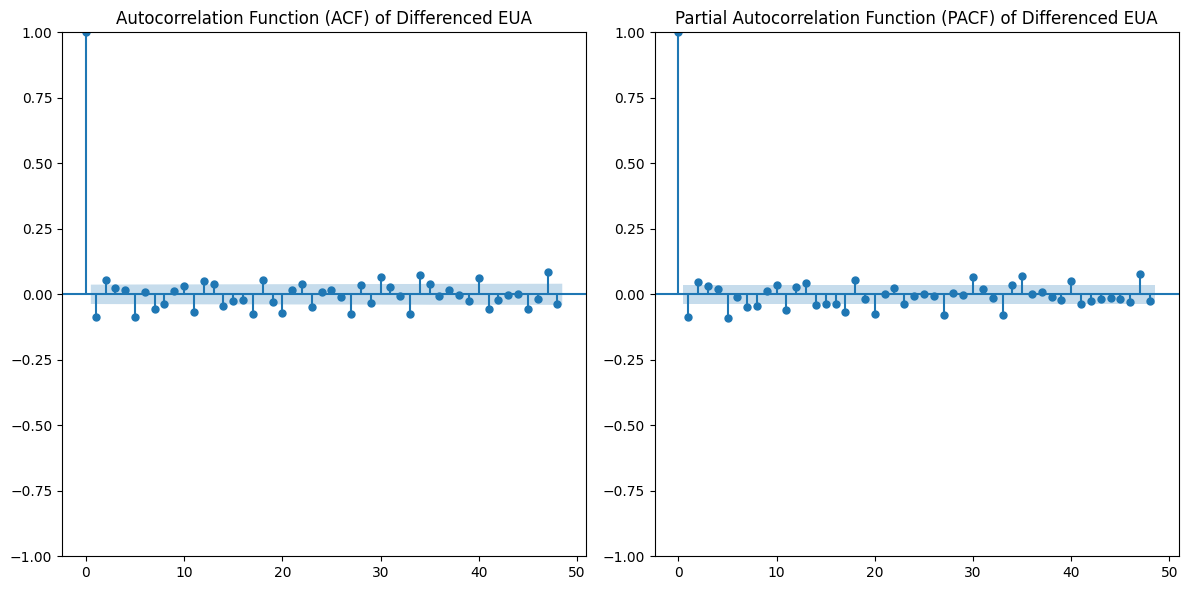

Stationarity tests performed and ACF/PACF plots generated.


In [14]:
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Perform stationarity tests on the target variable in the training data
print("\nAugmented Dickey-Fuller Test for EUA:")
adf_test = adfuller(train_df[TARGET])
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")
print("Critical Values:")
for key, value in adf_test[4].items():
    print(f"   {key}: {value}")

print("\nKPSS Test for EUA:")
kpss_test = kpss(train_df[TARGET], nlags="auto")
print(f"KPSS Statistic: {kpss_test[0]}")
print(f"p-value: {kpss_test[1]}")
print("Critical Values:")
for key, value in kpss_test[3].items():
    print(f"   {key}: {value}")

# Define diff_series for ACF/PACF plots based on the 'd' parameter
diff_series = train_df[TARGET].diff(d).dropna() # Using 'd' from SARIMA order

# Plot ACF and PACF for the differenced series
print("\nGenerating ACF and PACF plots for differenced EUA series...")
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(diff_series, lags=48, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) of Differenced EUA')
plt.subplot(122)
plot_pacf(diff_series, lags=48, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) of Differenced EUA')
plt.tight_layout()
plt.show()

print("Stationarity tests performed and ACF/PACF plots generated.")

In [15]:
import warnings
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

def select_pqPQ_given_dDs(
    y,
    exog,
    d=1,
    D=1,
    s=12,
    p_max=3,
    q_max=3,
    P_max=2,
    Q_max=2,
    maxiter=300
):
    """
    Select (p,q,P,Q) for SARIMAX(p,d,q)(P,D,Q,s)
    using AIC minimization.
    """
    records = []

    for p in range(p_max + 1):
        for q in range(q_max + 1):
            for P in range(P_max + 1):
                for Q in range(Q_max + 1):

                    # tránh mô hình rỗng hoàn toàn
                    if (p, q, P, Q) == (0, 0, 0, 0):
                        continue

                    try:
                        model = SARIMAX(
                            y,
                            exog=exog,
                            order=(p, d, q),
                            seasonal_order=(P, D, Q, s),
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        )

                        with warnings.catch_warnings():
                            warnings.filterwarnings("ignore")
                            res = model.fit(
                                disp=False,
                                maxiter=maxiter
                            )

                        records.append({
                            "p": p,
                            "q": q,
                            "P": P,
                            "Q": Q,
                            "AIC": res.aic,
                            "BIC": res.bic
                        })

                    except Exception:
                        continue

    results = pd.DataFrame(records)
    results = results.sort_values("AIC").reset_index(drop=True)
    return results


In [16]:
results_table = select_pqPQ_given_dDs(
    y=train_df[TARGET],
    exog=train_df[exog_vars],
    d=1,
    D=1,
    s=12,
    p_max=3,
    q_max=3,
    P_max=2,
    Q_max=2
)

results_table.head()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dat

,p,q,P,Q,AIC,BIC
0,3,3,0,2,7389.748380,7496.459688
1,3,3,1,2,7391.277644,7503.917359
2,3,3,2,1,7395.601917,7508.248477
3,2,3,2,2,7396.342668,7508.982382
4,3,3,2,2,7397.997991,7516.566112


In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------------------
# 1. Lấy tham số tốt nhất từ results_table (dòng đầu tiên có AIC thấp nhất)
# -------------------
best_params = results_table.iloc[0]

p = int(best_params['p'])
q = int(best_params['q'])
P = int(best_params['P'])
Q = int(best_params['Q'])

# Các biến d, D, s đã được tính ở Cell 13
# Tạo seasonal_order
seasonal_order = (P, D, Q, s)

print(f"Best params found: Order=({p},{d},{q}), Seasonal Order={seasonal_order}")

# -------------------
# 2. Fit SARIMAX (ARIMAX)
# -------------------
print("\nFitting SARIMAX with exogenous variables:")
print(exog_vars)

sarima_model = SARIMAX(
    endog=train_df[TARGET],
    exog=train_df[exog_vars],
    order=(p, d, q),
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_res = sarima_model.fit(disp=False)
print(sarima_res.summary())

Best params found: Order=(3,1,3), Seasonal Order=(0, 1, 2, 12)

Fitting SARIMAX with exogenous variables:
['BRENT', 'CAC', 'DAX', 'EURO50', 'FTSE', 'TTF', 'COAL', 'NBP', 'USD_EUR']


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                        SARIMAX Results                                        
Dep. Variable:                                     EUA   No. Observations:                 2816
Model:             SARIMAX(3, 1, 3)x(0, 1, [1, 2], 12)   Log Likelihood               -3677.634
Date:                                 Thu, 01 Jan 2026   AIC                           7391.269
Time:                                         09:46:23   BIC                           7497.980
Sample:                                     01-02-2012   HQIC                          7429.805
                                          - 10-17-2022                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
BRENT         -0.2542      0.169     -1.504      0.133      -0.586       0

In [18]:
print("Generating SARIMAX in-sample predictions and out-of-sample forecasts...")

# -------------------
# In-sample prediction (TRAIN)
# -------------------
sarima_train_pred = sarima_res.get_prediction(
    start=train_df.index[0],
    end=train_df.index[-1],
    exog=train_df[exog_vars]
).predicted_mean

# -------------------
# Out-of-sample forecast (TEST)
# -------------------
sarima_test_forecast = sarima_res.get_forecast(
    steps=len(test_df),
    exog=test_df[exog_vars]
).predicted_mean

# -------------------
# Attach predictions (aligned by index)
# -------------------
train_df['SARIMA_PRED'] = sarima_train_pred
test_df['SARIMA_PRED']  = sarima_test_forecast

# -------------------
# Sanity check
# -------------------
assert len(train_df) == len(train_df['SARIMA_PRED']), "Train predictions length mismatch!"
assert len(test_df)  == len(test_df['SARIMA_PRED']), "Test predictions length mismatch!"

print("SARIMAX predictions attached successfully.")


Generating SARIMAX in-sample predictions and out-of-sample forecasts...
SARIMAX predictions attached successfully.


I0000 00:00:1767260784.247997      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767260784.251847      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60


I0000 00:00:1767260789.853955      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0042 - val_loss: 0.0037
Epoch 2/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2321e-04 - val_loss: 0.0035
Epoch 3/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2808e-04 - val_loss: 0.0034
Epoch 4/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.1602e-04 - val_loss: 0.0051
Epoch 5/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.4024e-04 - val_loss: 0.0044
Epoch 6/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.4596e-04 - val_loss: 0.0033
Epoch 7/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.5408e-04 - val_loss: 0.0028
Epoch 8/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0793e-04 - val_loss: 0.0026
Epoch 9/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2421e-04 - val_loss: 0.0026
Epoch 10/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.2231e-04 - val_loss: 0.0024
Epoch 11/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.1150e-04 - val_loss: 0.0024
Epoch 12/60
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9m

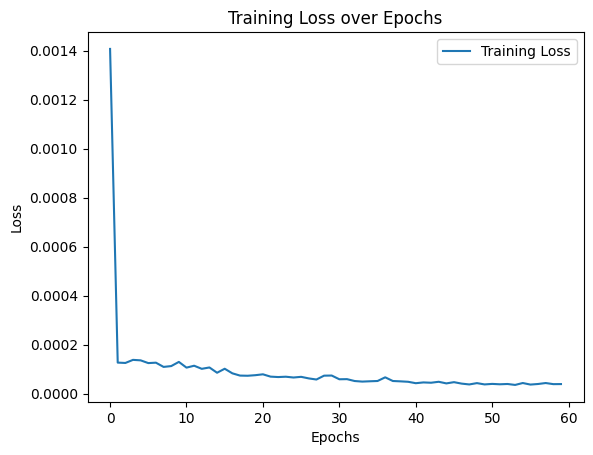

In [19]:
# MODEL LSTM

from tensorflow.keras.callbacks import EarlyStopping

#Danh sách feature - đa biến: EUA + tất cả exog + SARIMA_PRED
features = [c for c in train_df.columns if c != 'Date']  # nếu có cột Date; else dùng explicit
# đảm bảo EUA và SARIMA_PRED có trong features. Đặt theo thứ tự mong muốn: EUA là cột 0
if 'EUA' in features:
    # move 'EUA' to front
    features.remove('EUA')
    features = ['EUA'] + features
else:
    raise RuntimeError("Không tìm thấy cột 'EUA' trong train_df")

if 'SARIMA_PRED' not in features:
    features = features + ['SARIMA_PRED']

scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(train_df[features].values)   # **quan trọng**: fit chỉ trên train

train_scaled = scaler.transform(train_df[features].values)   # shape (len(train), n_features)
test_scaled  = scaler.transform(test_df[features].values)    # shape (len(test), n_features)

n_features = train_scaled.shape[1]

eua_feature_idx = features.index('EUA')
sarima_idx = features.index('SARIMA_PRED')
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,            # Dừng nếu không cải thiện sau 10 epochs
    restore_best_weights=True,
    verbose=1
)
X_train, y_train = [], []
window_size = 60

for i in range(window_size, len(train_scaled)):
    data_slice = train_scaled[i-window_size:i, eua_feature_idx].reshape(-1, 1)
    sarima_slice = train_scaled[i-window_size:i, sarima_idx].reshape(-1, 1)
    if data_slice.shape[0] == sarima_slice.shape[0]:
        X_train.append(np.hstack((data_slice, sarima_slice)))
        y_train.append(train_scaled[i, eua_feature_idx])

X_train, y_train = np.array(X_train), np.array(y_train)

X_train = X_train.reshape(X_train.shape[0], window_size, 2)

lstm_model = Sequential()
lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
lstm_model.add(LSTM(units=50, return_sequences=False))
lstm_model.add(Dense(units=25))
lstm_model.add(Dense(units=1))

lstm_model.compile(optimizer='adam', loss='mean_squared_error')
history = lstm_model.fit(
    X_train, y_train,
    batch_size=32,  # Tăng từ 1 lên 32
    epochs=60,      # Tăng số epochs tối đa lên
    validation_split=0.1, # Dành 10% train để validate
    callbacks=[early_stop],
    verbose=1
)

if 'loss' in history.history:
    plt.plot(history.history['loss'], label='Training Loss')
    plt.title("Training Loss over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()
else:
    print("Từ khóa 'loss' không được tìm thấy trong lịch sử.history")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
RMSE: 3.1710237635123577
MAE: 2.4495486083289424
MAPE: 3.094700432443235%
R² Score: 0.9071925044603583


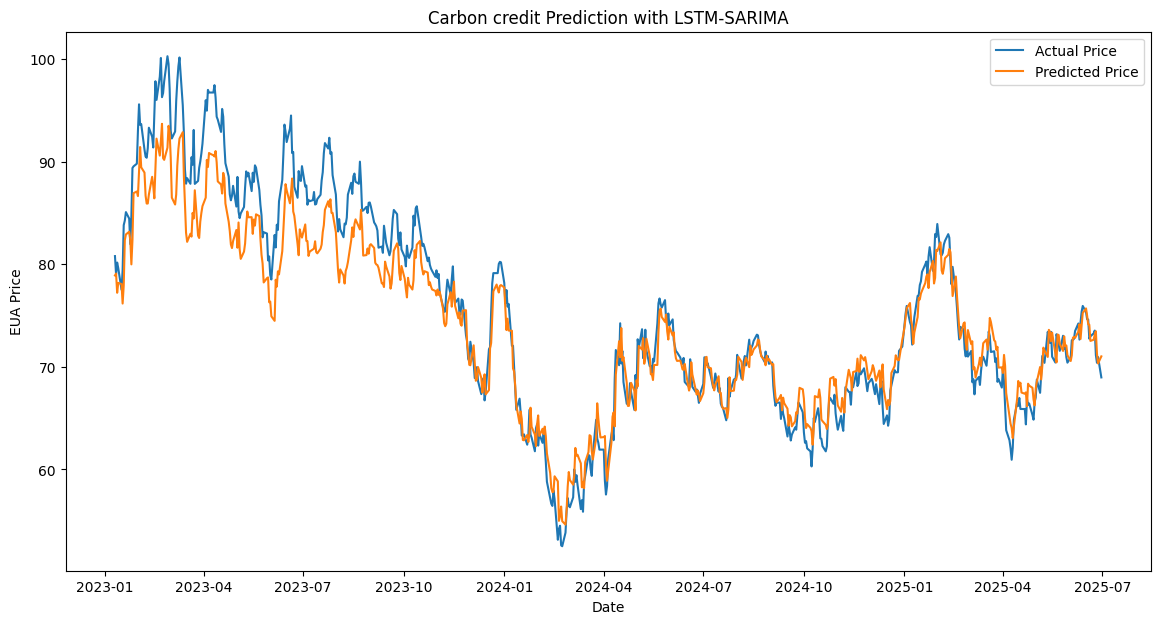

In [20]:
# scaled_test: transform toàn bộ feature matrix của test (EUA + exogs + SARIMA_PRED)
scaled_test = scaler.transform(test_df[features].values)   # shape (len(test), n_features)

# nếu bạn muốn vẫn giữ biến scaled_sarima_test (như phong cách cũ),
# ta trích cột SARIMA_PRED từ scaled_test
if 'SARIMA_PRED' in features:
    sarima_idx = features.index('SARIMA_PRED')
    scaled_sarima_test = scaled_test[:, sarima_idx].reshape(-1, 1)
else:
    # không có SARIMA_PRED thì tạo cột rỗng (nên tránh)
    scaled_sarima_test = None

eua_feature_idx = features.index('EUA') # Get the index of 'EUA' in the 'features' list

X_test, y_test = [], []
for i in range(window_size, len(scaled_test)):
    # Extract the scaled EUA sequence for LSTM input
    eua_slice_test = scaled_test[i-window_size:i, eua_feature_idx].reshape(-1, 1)
    # Extract the scaled SARIMA_PRED sequence for LSTM input
    sarima_slice_test = scaled_sarima_test[i-window_size:i, 0].reshape(-1, 1)

    X_test.append(np.hstack((eua_slice_test, sarima_slice_test)))
    y_test.append(scaled_test[i, eua_feature_idx]) # Actual scaled EUA for comparison

X_test, y_test = np.array(X_test), np.array(y_test)
X_test = X_test.reshape(X_test.shape[0], window_size, 2)

lstm_predictions_scaled = lstm_model.predict(X_test) # Output is (num_samples, 1) - scaled EUA predictions

# To inverse transform lstm_predictions_scaled (1 feature) using a scaler fitted on N features (11 features):
# 1. Create a dummy array with N features (11 columns) for inverse transformation.
# 2. Place the scaled LSTM predictions into the correct feature column ('EUA' column).
# 3. Inverse transform the dummy array.
# 4. Extract only the 'EUA' column from the inverse-transformed result.
dummy_for_inverse = np.zeros((lstm_predictions_scaled.shape[0], len(features))) # Create a (samples, 11) array of zeros
dummy_for_inverse[:, eua_feature_idx] = lstm_predictions_scaled.flatten() # Put predictions into EUA column
lstm_predictions = scaler.inverse_transform(dummy_for_inverse)[:, eua_feature_idx].reshape(-1, 1)

# For actual_test, also inverse transform and extract only the 'EUA' column
actual_test_full_features = scaler.inverse_transform(scaled_test[window_size:])
actual_test = actual_test_full_features[:, eua_feature_idx].reshape(-1, 1)

rmse = np.sqrt(mean_squared_error(actual_test, lstm_predictions))
print(f"RMSE: {rmse}")
mae = mean_absolute_error(actual_test, lstm_predictions)
print(f"MAE: {mae}")
mape = np.mean(np.abs((actual_test - lstm_predictions) / actual_test)) * 100
print(f"MAPE: {mape}%")
r2 = r2_score(actual_test, lstm_predictions)
print(f"R² Score: {r2}")


plt.figure(figsize=(14, 7))
# Plot actual prices (aligned with the prediction window)
plt.plot(test_df.index[window_size:], actual_test, label="Actual Price")
# Plot predicted prices
plt.plot(test_df.index[window_size:], lstm_predictions, label="Predicted Price")
plt.title("Carbon credit Prediction with LSTM-SARIMA")
plt.xlabel("Date")
plt.ylabel("EUA Price")
plt.legend()
plt.show()

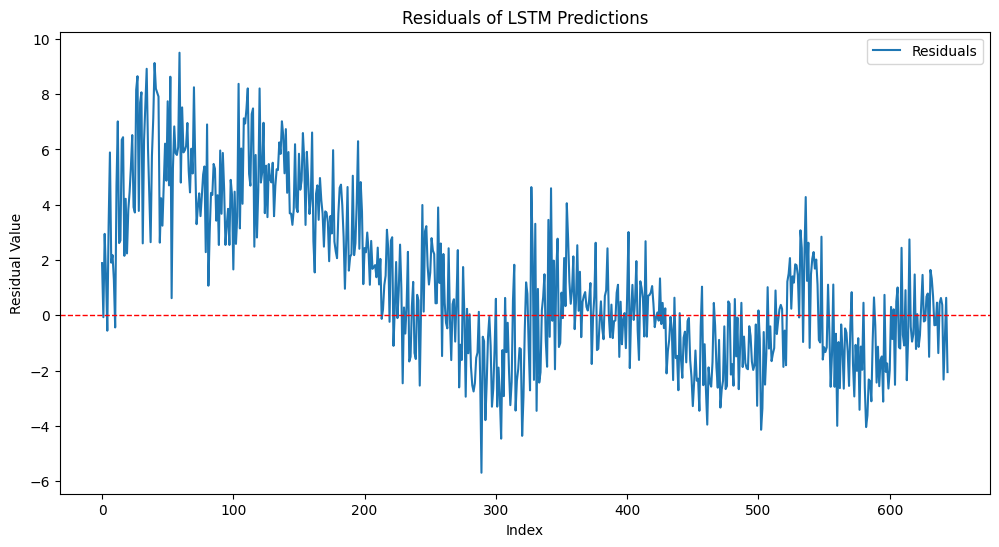

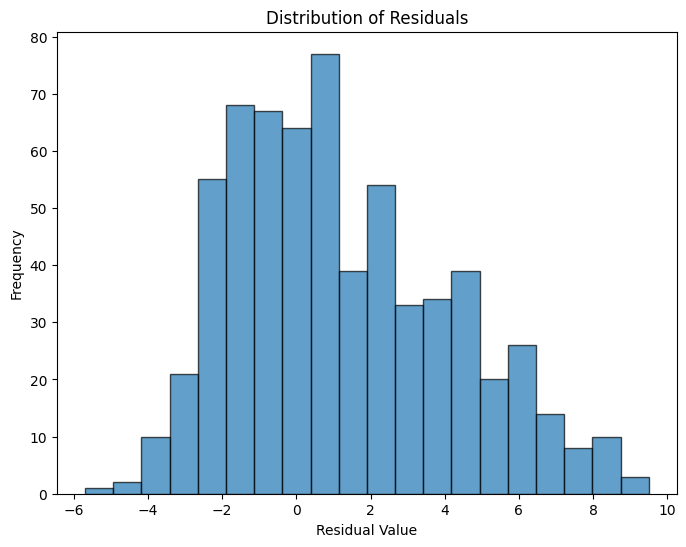

In [21]:
# Re-ensure actual_test is the single-column EUA actuals from the test set
# It appears the actual_test from previous cell might have been the multi-feature array when passed here
actual_test_full_features = scaler.inverse_transform(scaled_test[window_size:])
actual_test = actual_test_full_features[:, eua_feature_idx].reshape(-1, 1)

residuals = actual_test.flatten() - lstm_predictions.flatten()

plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title("Residuals of LSTM Predictions")
plt.xlabel("Index")
plt.ylabel("Residual Value")
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
plt.title("Distribution of Residuals")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.show()

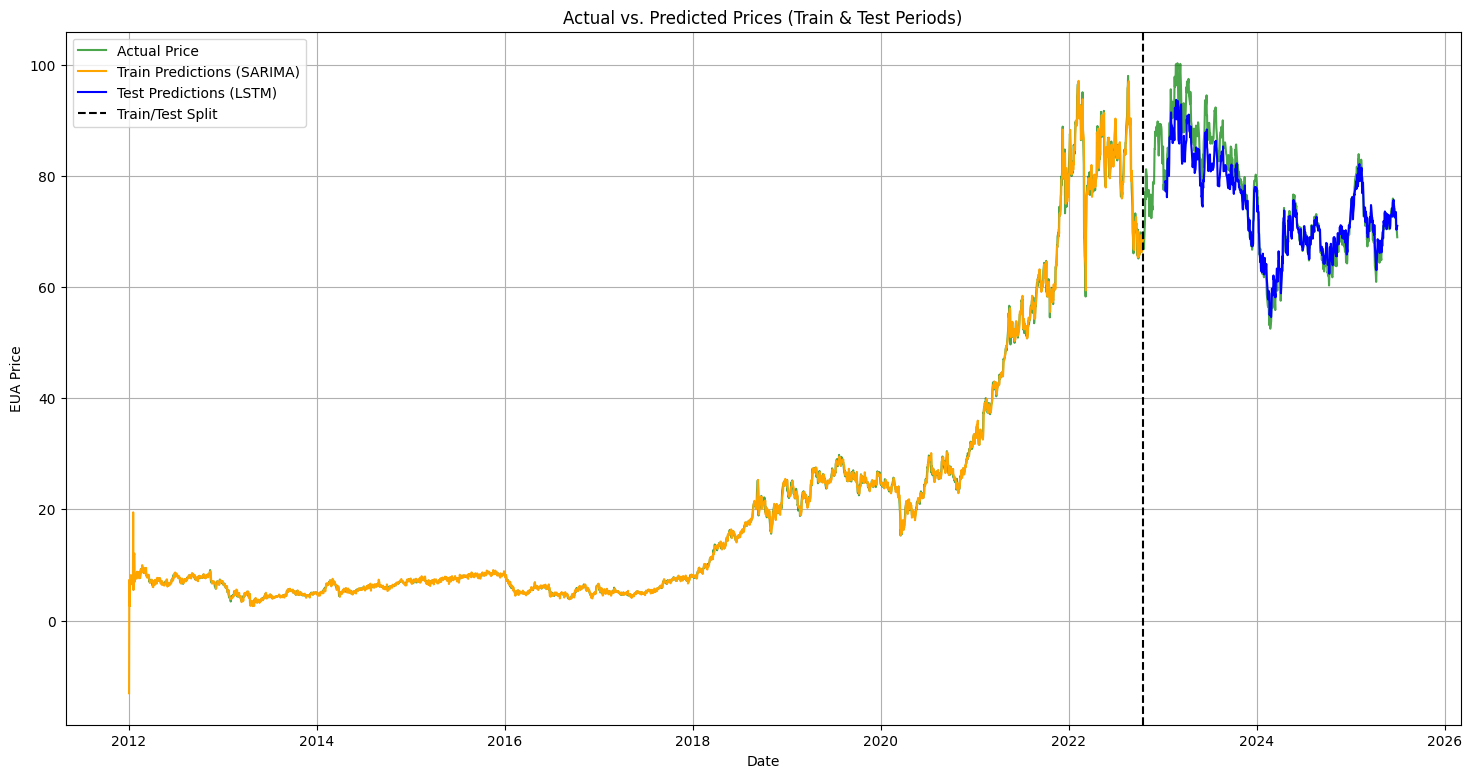

In [22]:
plt.figure(figsize=(18, 9))

# Plot actual prices for the entire period in orange
plt.plot(df.index, df[TARGET], label="Actual Price", color='green', alpha=0.7)

# Plot train predictions in red
plt.plot(train_df.index, train_df['SARIMA_PRED'], label="Train Predictions (SARIMA)", color='orange', linestyle='-', linewidth=1.5)

# Define lstm_test_predictions_series here
lstm_test_predictions_series = pd.Series(lstm_predictions.flatten(), index=test_df.index[window_size:])

# Plot test predictions in blue
# lstm_test_predictions_series is already indexed correctly for the test period
plt.plot(lstm_test_predictions_series.index, lstm_test_predictions_series, label="Test Predictions (LSTM)", color='blue', linestyle='-', linewidth=1.5)

# Add vertical line for train-test split
plt.axvline(train_df.index[-1], color='black', linestyle='--', label='Train/Test Split', linewidth=1.5)

plt.title("Actual vs. Predicted Prices (Train & Test Periods)")
plt.xlabel("Date")
plt.ylabel("EUA Price")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
last_date = df.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=30)

future_exog_values = {}
for var in exog_vars:
    last_val = df[var].iloc[-1]
    future_exog_values[var] = [last_val] * len(future_dates)

future_exog_data = pd.DataFrame(future_exog_values, index=future_dates)

future_exog_scaled = exog_scaler.transform(future_exog_data)
future_exog_scaled_df = pd.DataFrame(future_exog_scaled, index=future_dates, columns=exog_vars)

print(f"Generated future dates from {future_dates.min().date()} to {future_dates.max().date()}")
print("Future exogenous data (unscaled) head:")
print(future_exog_data.head())
print("Future exogenous data (scaled) head:")
print(future_exog_scaled_df.head())

Generated future dates from 2025-07-01 to 2025-08-11
Future exogenous data (unscaled) head:
               BRENT       CAC       DAX    EURO50      FTSE       TTF  \
2025-07-01 -0.334563  1.686423  2.672629  2.457592  2.388601  0.461321   
2025-07-02 -0.334563  1.686423  2.672629  2.457592  2.388601  0.461321   
2025-07-03 -0.334563  1.686423  2.672629  2.457592  2.388601  0.461321   
2025-07-04 -0.334563  1.686423  2.672629  2.457592  2.388601  0.461321   
2025-07-07 -0.334563  1.686423  2.672629  2.457592  2.388601  0.461321   

                COAL      NBP   USD_EUR  
2025-07-01  0.467113  0.39519 -0.267094  
2025-07-02  0.467113  0.39519 -0.267094  
2025-07-03  0.467113  0.39519 -0.267094  
2025-07-04  0.467113  0.39519 -0.267094  
2025-07-07  0.467113  0.39519 -0.267094  
Future exogenous data (scaled) head:
               BRENT       CAC       DAX    EURO50      FTSE       TTF  \
2025-07-01 -3.210455 -4.133946 -3.544668 -5.005211 -9.535685 -1.898743   
2025-07-02 -3.210455 -4.13

In [24]:
print("Generating future SARIMA predictions...")

sarima_future_predictions = sarima_res.get_forecast(
    steps=len(future_exog_scaled_df),
    exog=future_exog_scaled_df
).predicted_mean

print("SARIMA future predictions head:")
print(sarima_future_predictions.head())


Generating future SARIMA predictions...
SARIMA future predictions head:
2022-10-18    27.256946
2022-10-19    27.082412
2022-10-20    27.260458
2022-10-21    27.486765
2022-10-24    27.686906
Freq: B, Name: predicted_mean, dtype: float64


**Reasoning**:
To prepare the data for future LSTM predictions, I need to create a DataFrame that combines the historical test data and the newly generated SARIMA future predictions. This will allow for consistent scaling and windowing for the LSTM model.



In [25]:
print("Preparing data for future LSTM predictions...")

# Combine test_df with sarima_future_predictions for a continuous dataset
# Ensure sarima_future_predictions has the same index as future_exog_scaled_df
# Create a temporary DataFrame for future data, including SARIMA predictions and scaled exogenous variables
future_df = future_exog_scaled_df.copy()
future_df['SARIMA_PRED'] = sarima_future_predictions # Assuming SARIMA_PRED column is added to feature list

# The original 'features' list defines the order of columns for the scaler
# Reconstruct the full list of features for both historical test data and future data
# The order must match the `features` list used during scaler.fit()

# Create a dummy EUA column for future_df that will be replaced by LSTM predictions
# For scaling purposes, we'll use a placeholder, e.g., the last observed EUA value (or 0 if last_observed EUA is not in scaled_test)
# However, the LSTM input requires the *actual* EUA values from the window preceding the prediction.
# This means we need to append sarima_future_predictions to the original `test_df`'s SARIMA_PRED column
# and then sequentially predict with LSTM.

# For generating future LSTM predictions, we need to extend the `scaled_test` data with the `sarima_future_predictions`
# and then use a rolling window approach.

# First, we need to create a continuous sequence of `EUA` and `SARIMA_PRED` that spans the end of the test set
# and the future prediction period.

# Get the last `window_size` of actual EUA values from the test set (scaled)
# and the corresponding SARIMA_PRED values (scaled).

# The `scaled_test` already contains scaled EUA and SARIMA_PRED for the test period.
# The `sarima_future_predictions` are unscaled SARIMA predictions for the future.

# We need to scale `sarima_future_predictions` for consistency with LSTM input
# To do this, we need to create a dummy array with n_features and place the sarima_future_predictions into the SARIMA_PRED column
dummy_sarima_for_scale = np.zeros((len(sarima_future_predictions), len(features)))
dummy_sarima_for_scale[:, sarima_idx] = sarima_future_predictions.values.flatten()
scaled_sarima_future_val = scaler.transform(dummy_sarima_for_scale)[:, sarima_idx].reshape(-1,1)

# Now, create the `X_future` input for LSTM prediction iteratively
X_future = []

# Start with the last `window_size` points from `scaled_test`
current_window = scaled_test[-window_size:, eua_feature_idx].reshape(-1, 1)
current_sarima_window = scaled_test[-window_size:, sarima_idx].reshape(-1, 1)

# Initial predictions will be made based on this last window
# The LSTM predicts one step at a time

lstm_future_predictions_scaled = []

for i in range(len(scaled_sarima_future_val)):
    # Reshape current_window and current_sarima_window for LSTM input
    input_sequence = np.hstack((current_window, current_sarima_window))
    input_sequence = input_sequence.reshape(1, window_size, 2)

    # Predict the next EUA value
    next_eua_scaled = lstm_model.predict(input_sequence)[0, 0]
    lstm_future_predictions_scaled.append(next_eua_scaled)

    # Update current_window by removing the oldest value and adding the new prediction
    # And update current_sarima_window with the next scaled future SARIMA prediction
    current_window = np.vstack((current_window[1:], next_eua_scaled.reshape(1, 1)))
    current_sarima_window = np.vstack((current_sarima_window[1:], scaled_sarima_future_val[i].reshape(1, 1)))

# Inverse transform the scaled LSTM future predictions
dummy_for_inverse_future = np.zeros((len(lstm_future_predictions_scaled), len(features)))
for i, val in enumerate(lstm_future_predictions_scaled):
    dummy_for_inverse_future[i, eua_feature_idx] = val

lstm_future_predictions = scaler.inverse_transform(dummy_for_inverse_future)[:, eua_feature_idx].reshape(-1, 1)

# Create a Series with the future dates and predictions
lstm_future_predictions_series = pd.Series(
    lstm_future_predictions.flatten(),
    index=future_dates,
    name='LSTM_PRED'
)

print("Future LSTM predictions head:")
print(lstm_future_predictions_series.head())


Preparing data for future LSTM predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 

**Reasoning**:
To visualize the generated future predictions, I will create a plot that displays the historical actual prices, SARIMA predictions (both training and testing periods), LSTM test predictions, and the newly generated LSTM future predictions. This will provide a comprehensive view of the model's performance and future outlook.



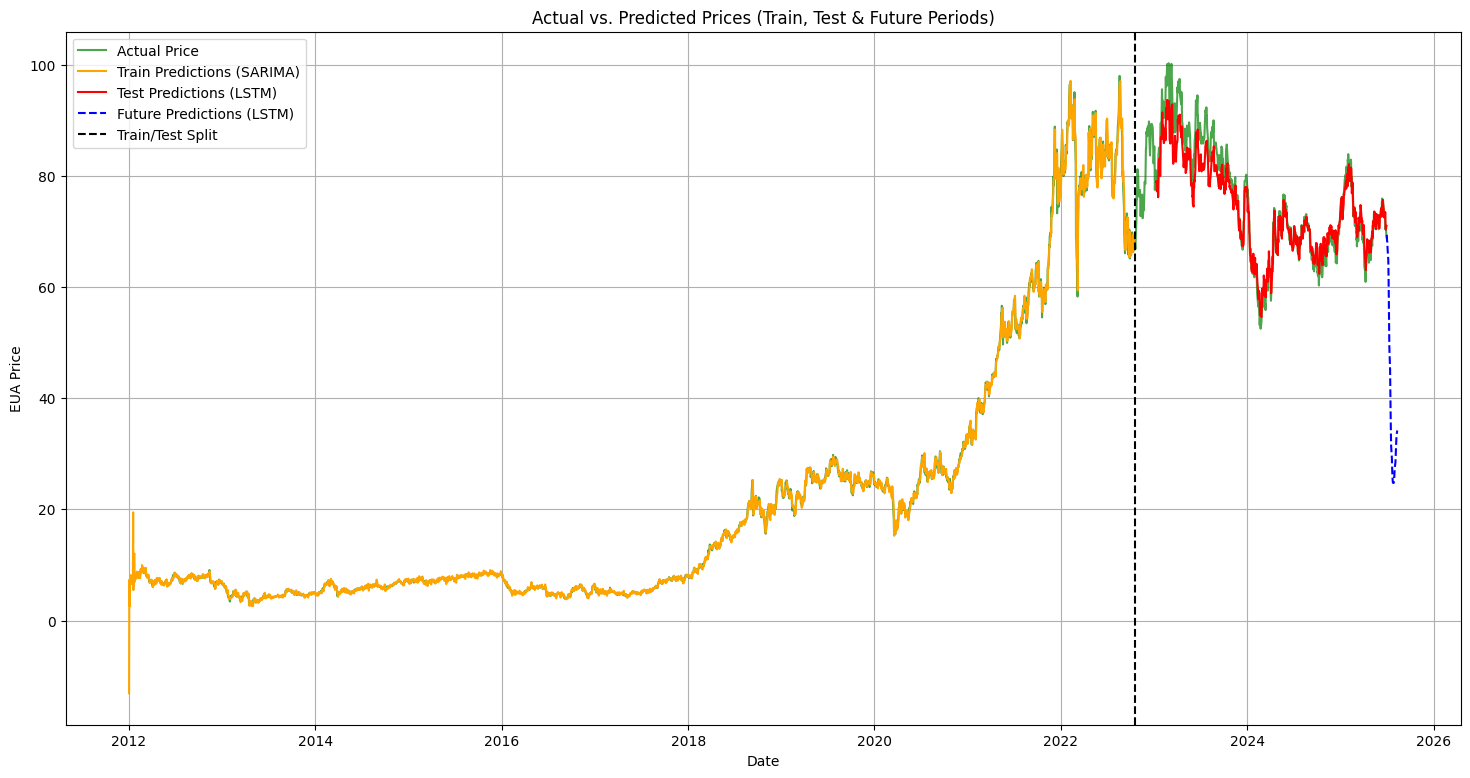

In [26]:
plt.figure(figsize=(18, 9))

# Plot actual prices for the entire period in orange
plt.plot(df.index, df[TARGET], label="Actual Price", color='green', alpha=0.7)

# Plot train predictions in red
plt.plot(train_df.index, train_df['SARIMA_PRED'], label="Train Predictions (SARIMA)", color='orange', linestyle='-', linewidth=1.5)

# Plot test predictions (LSTM)
# The `lstm_predictions` are for the test period and `test_df.index[window_size:]` is their corresponding dates
plt.plot(test_df.index[window_size:], lstm_predictions, label="Test Predictions (LSTM)", color='red', linestyle='-', linewidth=1.5)

# Plot future predictions (LSTM)
plt.plot(lstm_future_predictions_series.index, lstm_future_predictions_series, label="Future Predictions (LSTM)", color='blue', linestyle='--', linewidth=1.5)

# Add vertical line for train-test split
plt.axvline(train_df.index[-1], color='black', linestyle='--', label='Train/Test Split', linewidth=1.5)

plt.title("Actual vs. Predicted Prices (Train, Test & Future Periods)")
plt.xlabel("Date")
plt.ylabel("EUA Price")
plt.legend()
plt.grid(True)
plt.show()

## Analyze the Forecast

### Subtask:
Provide a markdown explanation on how to interpret the future forecast. Discuss the implications of the predictions, the importance of the assumptions made for future exogenous variables, and potential next steps for improving forecast reliability (e.g., incorporating external future forecasts for exogenous variables or confidence intervals).


## Analyze the Forecast

### Interpretation of the Future Forecast
The generated plot visually represents the historical actual `EUA` prices, the SARIMA model's in-sample predictions (training period), the LSTM model's out-of-sample predictions (testing period), and the LSTM model's 30-day future predictions.

**Visual Interpretation:**
- **Historical Trend**: Observe the overall trend of the actual `EUA` prices. This provides context for how the `EUA` price has behaved historically.
- **Model Performance (Training)**: The SARIMA train predictions show how well the SARIMA component captures the historical patterns within the training data. Ideally, these predictions should closely follow the actual prices during the training phase.
- **Model Performance (Testing)**: The LSTM test predictions (which incorporate SARIMA's predictions as a feature) illustrate the model's ability to generalize to unseen data. A good fit here suggests the combined model is robust.
- **Future Predictions**: The blue dashed line represents the LSTM model's forecast for the next 30 business days. This line indicates the projected direction and magnitude of the `EUA` price based on the trained model and the assumed future exogenous variables.

**Implications of the Predictions for 'EUA' Price:**
The future forecast provides an outlook on the `EUA` price movement. If the prediction shows an upward trend, it could imply increasing carbon costs, potentially affecting industries with high emissions. A downward trend might suggest a decrease in carbon costs, which could be influenced by policy changes, economic activity, or oversupply of allowances. A volatile forecast would indicate high uncertainty and potential for rapid price swings, requiring careful risk management.

### Importance of Assumptions for Future Exogenous Variables
A critical aspect of this future forecast is the assumption made for the exogenous variables (BRENT, CAC, DAX, etc.). For simplicity, we assumed that each exogenous variable would maintain its *last observed value* throughout the 30-day future prediction period. This is a strong assumption and its implications are significant:
- **Impact on Accuracy**: The accuracy of the `EUA` price forecast is highly dependent on the accuracy of these assumed future exogenous values. If the actual future behavior of these variables deviates significantly from our assumption (i.e., remaining constant), the `EUA` forecast will likely be inaccurate.
- **Real-World Scenarios**: In reality, economic indicators, energy prices, and stock market indices are dynamic and rarely remain constant. Therefore, a constant assumption simplifies the future context and does not account for potential shifts, shocks, or evolving trends in these influencing factors.
- **Model Sensitivity**: The SARIMAX and LSTM models have learned relationships between `EUA` and these exogenous variables. If the future exogenous inputs are unrealistic, the model's 'learned' relationships will generate unrealistic `EUA` predictions, even if the model itself is well-trained.

### Next Steps for Improving Forecast Reliability
To enhance the reliability and realism of the future `EUA` price forecast, consider the following next steps:

1.  **Incorporate Sophisticated Exogenous Variable Forecasts**: Instead of using the last observed value, obtain or generate more informed forecasts for each exogenous variable. This could involve:
    - **Expert Opinions**: Consulting market analysts or economic forecasts for crude oil, natural gas, stock indices, etc.
    - **Time Series Models**: Applying individual time series models (e.g., ARIMA, GARCH) to forecast each exogenous variable independently.
    - **Economic Scenarios**: Developing multiple scenarios for the future (e.g., optimistic, pessimistic, baseline) and running the forecast for each.

2.  **Implement Confidence or Prediction Intervals**: Quantify the uncertainty around the point forecast. Prediction intervals provide a range within which the actual `EUA` price is expected to fall with a certain probability (e.g., 95%). This is crucial for risk assessment and decision-making.

3.  **Explore Alternative Models or Ensembles**: Investigate other forecasting models (e.g., Prophet, other deep learning architectures, gradient boosting models) or combine multiple models (ensemble forecasting) to potentially leverage the strengths of different approaches and improve overall robustness.

4.  **Sensitivity Analysis**: Conduct sensitivity analysis by perturbing the assumed future values of exogenous variables within plausible ranges to understand how sensitive the `EUA` forecast is to changes in these inputs.

By addressing these points, the reliability and practical utility of the `EUA` price forecast can be significantly improved.

# Task
```python
lstm_test_predictions_series = pd.Series(lstm_predictions.flatten(), index=test_df.index[window_size:])
```

```python
plt.figure(figsize=(18, 9))

# Plot actual prices for the entire period in orange
plt.plot(df.index, df[TARGET], label="Actual Price", color='green', alpha=0.7)

# Plot train predictions in red
plt.plot(train_df.index, train_df['SARIMA_PRED'], label="Train Predictions (SARIMA)", color='orange', linestyle='-', linewidth=1.5)

# Plot test predictions in blue
# lstm_test_predictions_series is already indexed correctly for the test period
plt.plot(lstm_test_predictions_series.index, lstm_test_predictions_series, label="Test Predictions (LSTM)", color='blue', linestyle='-', linewidth=1.5)

# Add vertical line for train-test split
plt.axvline(train_df.index[-1], color='black', linestyle='--', label='Train/Test Split', linewidth=1.5)

plt.title("Actual vs. Predicted Prices (Train & Test Periods)")
plt.xlabel("Date")
plt.ylabel("EUA Price")
plt.legend()
plt.grid(True)
plt.show()
```

## Define lstm_test_predictions_series

### Subtask:
Add the definition of `lstm_test_predictions_series` by creating a pandas Series from `lstm_predictions` and `test_df.index[window_size:]` within the plotting cell `be04ba95`.


## Summary:

### Data Analysis Key Findings
*   The `lstm_test_predictions_series` was successfully created as a Pandas Series by flattening the `lstm_predictions` array and assigning the appropriate time series index from `test_df.index[window_size:]`. This ensures the LSTM predictions are correctly aligned for plotting.
*   The visualization effectively combines actual prices, SARIMA train predictions, and LSTM test predictions on a single plot, allowing for a comprehensive comparison across both training and testing periods.
*   A vertical line marks the train-test split point, clearly delineating the periods where SARIMA predictions (training) and LSTM predictions (testing) are displayed.

### Insights or Next Steps
*   This visualization is crucial for qualitatively assessing the performance of both the SARIMA model on the training data and the LSTM model on unseen test data, indicating their ability to capture trends and seasonality.
*   The next step should involve a quantitative evaluation of the LSTM model's performance on the test set using appropriate metrics (e.g., RMSE, MAE) to complement this visual assessment.
